我想要看看均线的斜率，这斜率暂时用涨幅来替代，

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
# matplotlib.use('agg')
import matplotlib.pyplot as plt
import os
# from tqdm.notebook import  tqdm
from tqdm import  tqdm
import talib
import datetime
import math
import  mplfinance as mpf

import sys
sys.path.append('../../DataSource/baostock')
import datasource
sys.path.append('../..')
import Utils
# 这个是筛选多少天上涨多少的，
codes = datasource.get_codes()
print(f'股票数量:{len(codes)},第一支股票:{codes[0]}')
code = codes[0]
dt = datasource.getData(code)
dt.head()

股票数量:5521,第一支股票:sh.600000


,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,peTTM,pbMRQ,psTTM,pcfNcfTTM,isST
date,,,,,,,,,,,,,,,,,
2010-01-04,sh.600000,64.829140,64.947929,62.839423,62.928515,64.413379,66191338,1.419984e+09,1,0.835129,1,-2.3052,14.435065,2.877081,5.316299,7.091240,0
2010-01-05,sh.600000,63.581855,64.086709,61.740624,63.403671,62.928515,115147943,2.436891e+09,1,1.452808,1,0.7551,14.287342,2.898805,5.178308,7.144784,0
2010-01-06,sh.600000,63.225488,63.255185,62.007900,62.156386,63.403671,96782575,2.034174e+09,1,1.221095,1,-1.9672,14.006279,2.841779,5.076439,7.004231,0
2010-01-07,sh.600000,62.007900,62.483056,60.285458,60.760614,62.156386,85236072,1.761801e+09,1,1.075414,1,-2.2456,13.691757,2.777965,4.962444,6.846945,0
2010-01-08,sh.600000,60.404247,61.770322,60.285458,61.443652,60.760614,65707646,1.349532e+09,1,0.829026,1,1.1241,13.845672,2.809193,5.018229,6.923915,0


In [3]:
dt['preClose']=dt['close'].shift()
dt['upRate']= (dt['close']-dt['preClose'])/dt['preClose']*100
dt = dt.dropna()
dt.head()

,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,peTTM,pbMRQ,psTTM,pcfNcfTTM,isST,preClose,upRate
date,,,,,,,,,,,,,,,,,,,
2010-01-05,sh.600000,63.581855,64.086709,61.740624,63.403671,62.928515,115147943,2.436891e+09,1,1.452808,1,0.7551,14.287342,2.898805,5.178308,7.144784,0,62.928515,0.755073
2010-01-06,sh.600000,63.225488,63.255185,62.007900,62.156386,63.403671,96782575,2.034174e+09,1,1.221095,1,-1.9672,14.006279,2.841779,5.076439,7.004231,0,63.403671,-1.967213
2010-01-07,sh.600000,62.007900,62.483056,60.285458,60.760614,62.156386,85236072,1.761801e+09,1,1.075414,1,-2.2456,13.691757,2.777965,4.962444,6.846945,0,62.156386,-2.245581
2010-01-08,sh.600000,60.404247,61.770322,60.285458,61.443652,60.760614,65707646,1.349532e+09,1,0.829026,1,1.1241,13.845672,2.809193,5.018229,6.923915,0,60.760614,1.124145
2010-01-11,sh.600000,64.146103,64.740049,61.087284,61.443652,61.443652,116304812,2.456819e+09,1,1.467404,1,0.0000,13.845672,2.809193,5.018229,6.923915,0,61.443652,0.000000


In [4]:
dt.columns.tolist().index('upRate')

18

In [5]:
dts = []
dict_counts = {}
DAYS_MAX = 20 # 最多20天
upRate_index = dt.columns.tolist().index('upRate') # 这列的下标
upRate_range_max = 1 # 涨幅范围最大
days_min = 3  # 最低3天
# 遍历日期
i = 0
while i < len(dt):
    # 遍历所有天数
    for j in range(DAYS_MAX, days_min, -1):
        # 截取当天和以后多天的数据
        dt2 = dt.iloc[i:(i+j), :]
        # 然后判断是否足够天数
        if len(dt2) < j:
            # 不够天数救下一次吧
            continue
        # 这里判断这几天是否曲线斜率差不多
        _max = dt2['upRate'].max()
        _min = dt2['upRate'].min()
        _mean = dt2['upRate'].mean()
        # 最大值和最小值的差在这个范围内，
        if _max - _min <= upRate_range_max:
            # 这里需要将平均值做截断处理
            _mean = np.around(_mean, decimals=1)
            dts.append((_mean.item(), j))
            # 
            # 添加最大的就退出吧
            break
    # 下一个
    i += 1
# 然后将列表转成数组
for i in dts:
    if i[0] not in dict_counts:
        dict_counts[i[0]] = 0
    dict_counts[i[0]] += i[1]

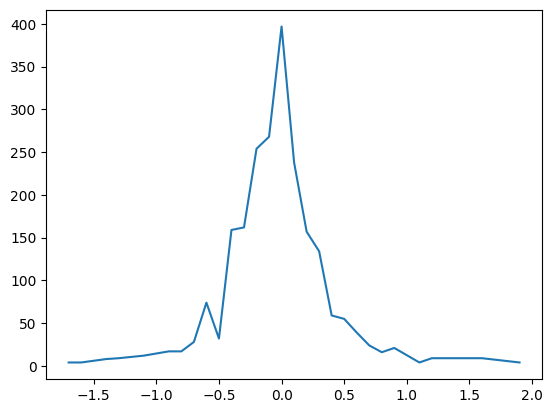

In [6]:
# 这里进行绘图
dt_all = [(key, dict_counts[key]) for key in dict_counts]
dt_all.sort(key=lambda x:x[0])
_x = [i[0] for i in dt_all]
_y = [i[1] for i in dt_all]
plt.plot(_x, _y)